In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from sklearn.cluster import MeanShift

Class to handle each image attribute, I used a class for this as each animal had it's own image, grayscale, threshold and path attributes, so handling this as an object felt easier.

In [12]:
imagesPath = "./Oxford-IIIT Pet Subset/image/"
annotationsPath = "./Oxford-IIIT Pet Subset/annotation/"


# Automate loading color and b/w images and annotations
class imageData:
    def __init__(self, Filename):
        self.name = Filename.split(".")[0]
        self.imagePath = os.path.join(imagesPath, Filename)

        # Why are the images .jpg while the annotations are .pngs, I found this out the hard way.
        self.annotationPath = os.path.join(annotationsPath, Filename.replace(".jpg", ".png"))
        
        # Setup the image attributes by opening the image and annotations then converting them to RGB and greyscale as needed.
        self.image = cv2.imread(self.imagePath)
        self.image = cv2.cvtColor(self.image, cv2.COLOR_BGR2RGB)
        self.annotation = cv2.imread(self.annotationPath)
        self.annotation = cv2.cvtColor(self.annotation, cv2.COLOR_BGR2RGB)
        self.image_grayscale = cv2.cvtColor(self.image, cv2.COLOR_BGR2GRAY)
        self.image_single_channel = cv2.imread(self.imagePath, 0)
        self.annotation_single_channel = cv2.imread(self.annotationPath, 0)
        self.annotation_greyscale = cv2.cvtColor(self.annotation, cv2.COLOR_BGR2GRAY)
        
        # Create a threshold for the animal, we will set this later when doing thresholding, as each image has a unique threshold value.
        self.Threshold = 0
        self.threshold_segmentation = np.empty(self.image_grayscale.shape, dtype=np.uint8)

        # Setup the attributes for watershed, make them empty for now.
        self.sure_bg = np.empty(self.image_grayscale.shape, dtype=np.uint8)
        self.sure_fg = np.empty(self.image_grayscale.shape, dtype=np.uint8)
        self.unknown = np.empty(self.image_grayscale.shape, dtype=np.uint8)
        self.markers = np.empty(self.image_grayscale.shape, dtype=np.int32)
        self.watershed = np.empty(self.image_grayscale.shape, dtype=np.uint8)

        self.kmeans_mask_RGB = np.empty(self.image_grayscale.shape, dtype=np.uint8)
        self.kmeans_mask_HSV = np.empty(self.image_grayscale.shape, dtype=np.uint8)
        self.kmeans_mask_spatial = np.empty(self.image_grayscale.shape, dtype=np.uint8)
        self.kmeans_mask_spatial_RGB = np.empty(self.image_grayscale.shape, dtype=np.uint8)


# Create objects for each animal
abyssinian = imageData("Abyssinian_19.jpg")
american_pit_bull_terrier = imageData("american_pit_bull_terrier_6.jpg")
beagle = imageData("beagle_1.jpg")
Bombay = imageData("Bombay_5.jpg")
Egyptian_Mau = imageData("Egyptian_Mau_1.jpg")

# Make an list to store all the animal objects
animals = [abyssinian, american_pit_bull_terrier, beagle, Bombay, Egyptian_Mau]


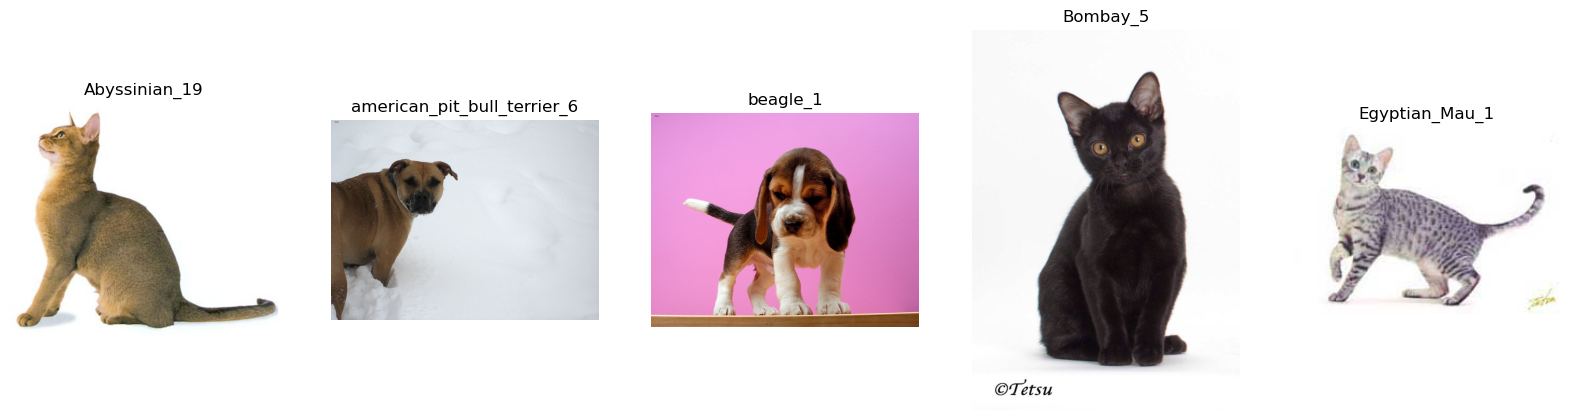

In [13]:
# Display the original images
plt.figure(figsize=(20, 10))
plt.subplot(1, len(animals), 1)
for animal in animals:
    plt.subplot(1, len(animals), animals.index(animal) + 1)
    plt.imshow(animal.image)
    plt.title(animal.name)
    plt.axis("off")
    
plt.show()

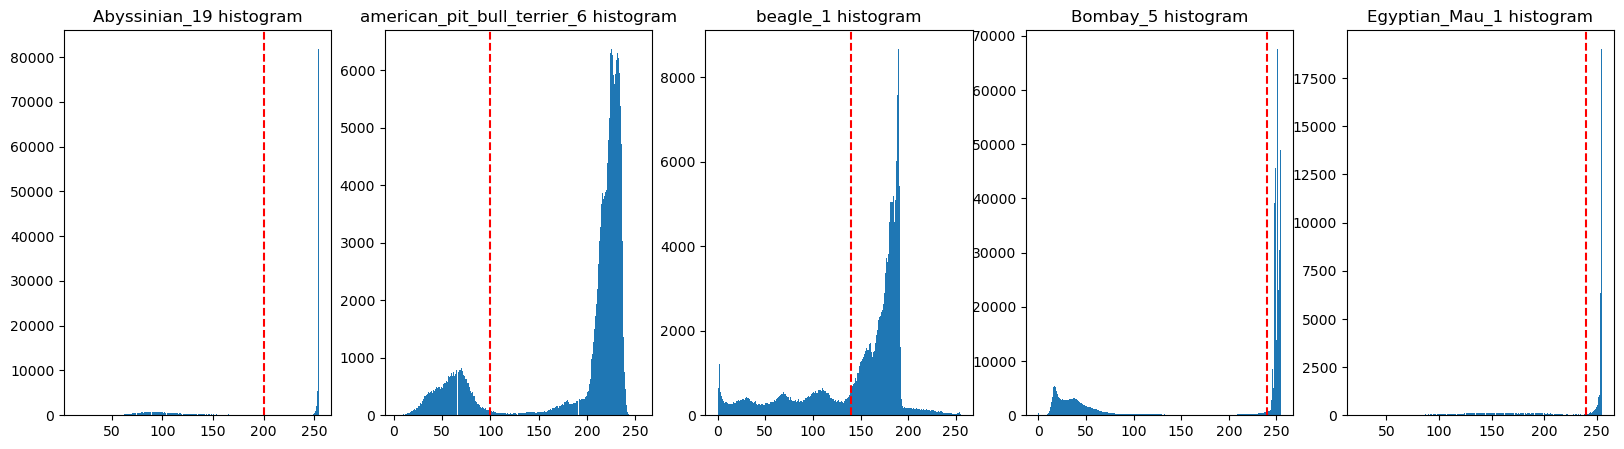

In [14]:
# Manually find a threshold for each image based off the histogram of the grayscale image. The thresholds are defined here to show a red line that indicates the selected threshold value on the histogram plots.

abyssinian.Threshold = 200
american_pit_bull_terrier.Threshold = 100
beagle.Threshold = 140
Bombay.Threshold = 240
Egyptian_Mau.Threshold = 240

plt.figure(figsize=(20, 5))
for animal in animals:
    plt.subplot(1, len(animals), animals.index(animal) + 1)
    plt.title(f"{animal.name} histogram")
    plt.hist(animal.image_grayscale.flatten(), bins=256)
    plt.axvline(x=animal.Threshold, color='r', linestyle='--')
plt.show()

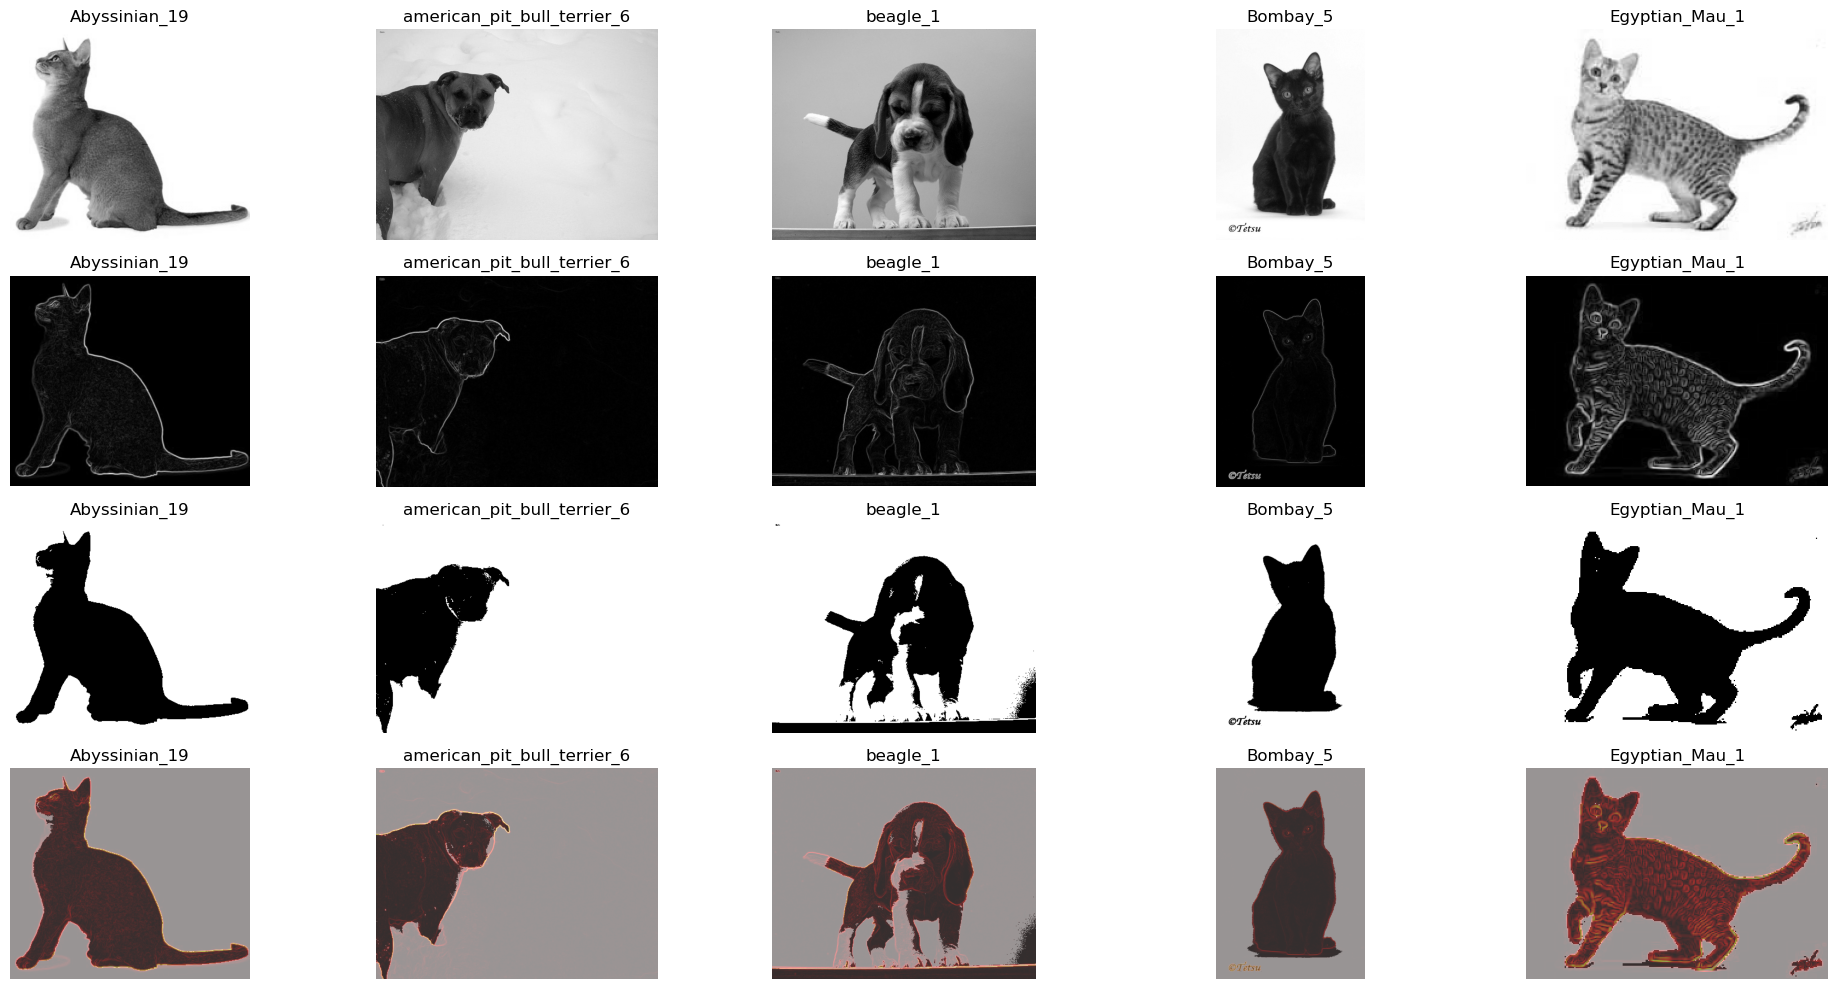

In [15]:
plt.figure(figsize=(20, 10))


# Display the grayscale images
for animal in animals:
    i = animals.index(animal) + 1
    plt.subplot(4, len(animals), i)
    plt.imshow(animal.image_grayscale, cmap="gray")
    plt.title(animal.name)
    plt.axis("off")

# Displaty the sobel edge detection
for animal in animals:
    i = animals.index(animal) + 1
    sobel_x = cv2.Sobel(animal.image_grayscale, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(animal.image_grayscale, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.sqrt(sobel_x**2 + sobel_y**2)
    sobel = np.uint8(sobel / (np.max(sobel) + 1e-8) * 255)

    plt.subplot(4, len(animals), len(animals) + i)
    plt.imshow(sobel, cmap="gray")
    plt.title(animal.name)
    plt.axis("off")

# Display the image through it's selected threshold value
for animal in animals:
    i = animals.index(animal) + 1
    _, binary = cv2.threshold(animal.image_grayscale, animal.Threshold, 255, cv2.THRESH_BINARY)
    animal.threshold_segmentation = binary
    

    plt.subplot(4, len(animals), 2 * len(animals) + i)
    plt.imshow(binary, cmap="gray")
    plt.title(animal.name)
    plt.axis("off")

# Display the threshold image overlayed on the sobel image
for animal in animals:
    i = animals.index(animal) + 1
    sobel_x = cv2.Sobel(animal.image_grayscale, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(animal.image_grayscale, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.sqrt(sobel_x**2 + sobel_y**2)
    sobel = np.uint8(sobel / (np.max(sobel) + 1e-8) * 255)

    _, binary = cv2.threshold(animal.image_grayscale, animal.Threshold, 255, cv2.THRESH_BINARY)
    animal.threshold_segmentation = binary

    plt.subplot(4, len(animals), 3 * len(animals) + i)
    plt.imshow(sobel, cmap="hot", alpha=0.7)
    plt.imshow(binary, cmap="grey", alpha=0.4)
    plt.title(animal.name)
    plt.axis("off")


plt.tight_layout()
plt.show()

In [16]:
# Define the Dice and IoU functions based off the tutorial work
def compute_dice(gt: np.ndarray, pred: np.ndarray) -> float:
    intersection = np.logical_and(gt, pred).sum()
    dice = (2 * intersection) / (gt.sum() + pred.sum()) if (gt.sum() + pred.sum()) > 0 else 0
    return dice

def compute_iou(gt, pred):
    intersection = np.logical_and(gt, pred).sum()
    union = np.logical_or(gt, pred).sum()
    iou = intersection / union if union > 0 else 0
    return iou

# Print the metrics
for animal in animals:
    print(f"{animal.name} Dice Coefficient: {compute_dice(animal.annotation_greyscale > 0, animal.threshold_segmentation > 0):.4f}")

print("---------------------------------")

for animal in animals:
    print(f"{animal.name} IoU: {compute_iou(animal.annotation_greyscale > 0, animal.threshold_segmentation > 0):.4f}")

Abyssinian_19 Dice Coefficient: 0.8074
american_pit_bull_terrier_6 Dice Coefficient: 0.9012
beagle_1 Dice Coefficient: 0.8369
Bombay_5 Dice Coefficient: 0.7985
Egyptian_Mau_1 Dice Coefficient: 0.8099
---------------------------------
Abyssinian_19 IoU: 0.6771
american_pit_bull_terrier_6 IoU: 0.8201
beagle_1 IoU: 0.7195
Bombay_5 IoU: 0.6645
Egyptian_Mau_1 IoU: 0.6805


In [ ]:
kernel = np.ones((3,3), np.uint8)

# Setup the sure forground/background, unknown region and markers for each animal
for animal in animals:
    # Blur the image

    blur = cv2.GaussianBlur(animal.image_grayscale, (3, 3), 0)

    # Apply Otsu's thresholding to the blurred image
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # apply dialation on the thresholded image to get the sure background, without the noise
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    animal.sure_bg = cv2.dilate(opening, kernel, iterations=1)

    # Apply distance transform to the image to get the sure forground
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

    # Threshold to get the sure forground, we will use 0.2 times the max value of the distance transform as the threshold value. (Value chosen based off tutorial)
    _, animal.sure_fg = cv2.threshold(dist_transform, 0.2*dist_transform.max(), 255, 0)
    animal.sure_fg = np.uint8(animal.sure_fg)

    # Unknown region is the area where neither the sure background or sure forground is present
    animal.unknown = cv2.subtract(animal.sure_bg, animal.sure_fg)

    # Assign a marker to each connected region, these markers will essentially act as seeds for the watershed algorithm
    _, animal.markers = cv2.connectedComponents(animal.sure_fg) 
    animal.markers = animal.markers + 1
    animal.markers[animal.unknown == 255] = 0
    

    # Apply the watershed algorithm
    animal.markers = cv2.watershed(animal.image, animal.markers)

    # Create a empty watershed image then apply the markers to the watershed algorithm, (without this, the images have weird lines, this fixed it)
    animal.watershed = np.zeros_like(animal.image_grayscale, dtype=np.uint8)
    animal.watershed[animal.markers == -1] = 255

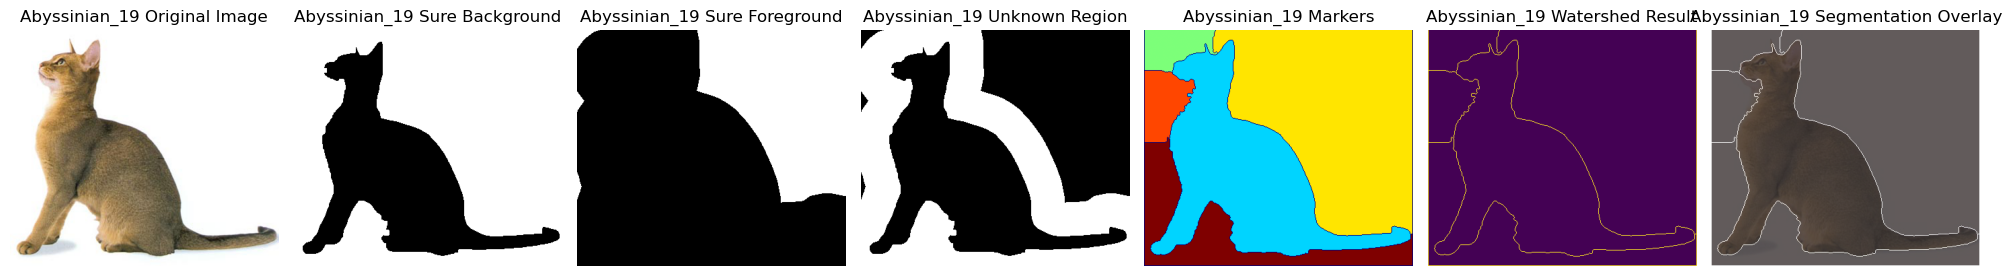

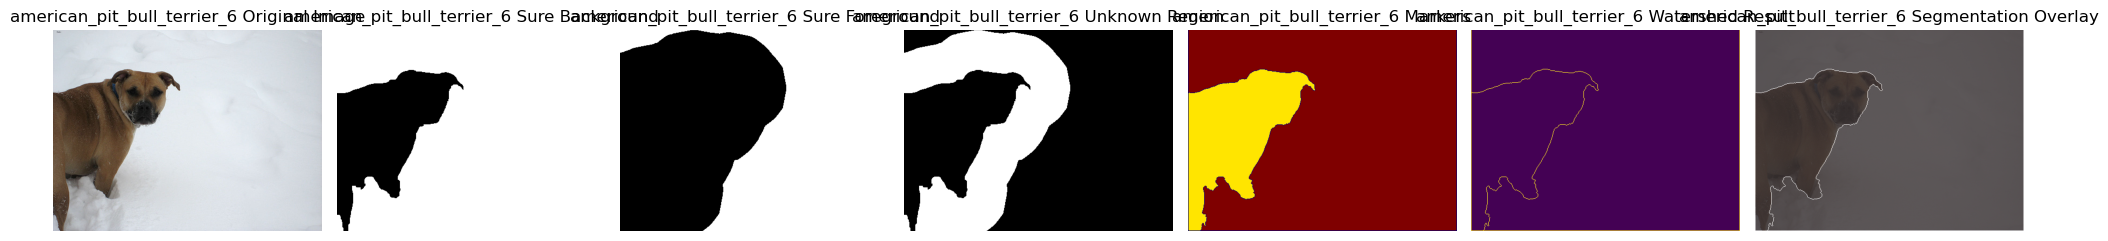

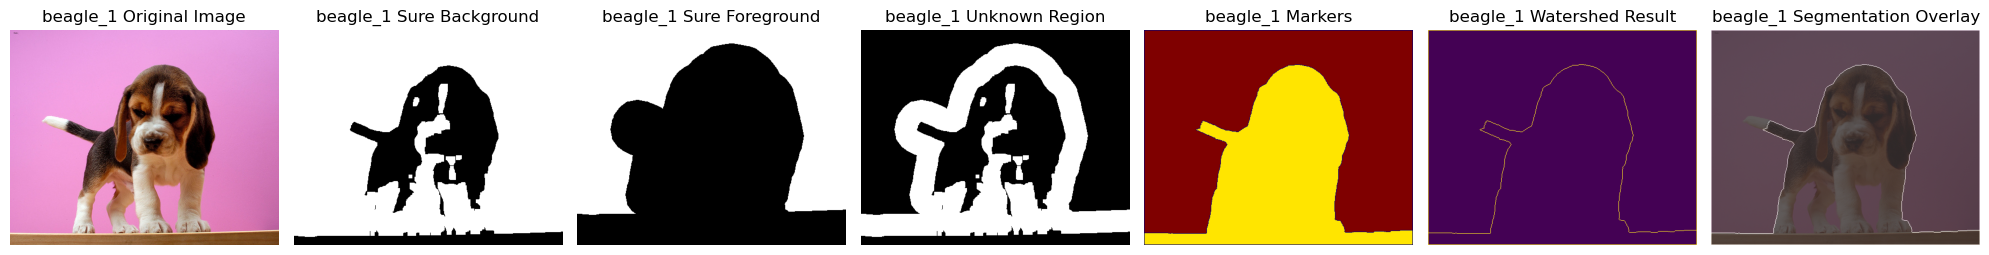

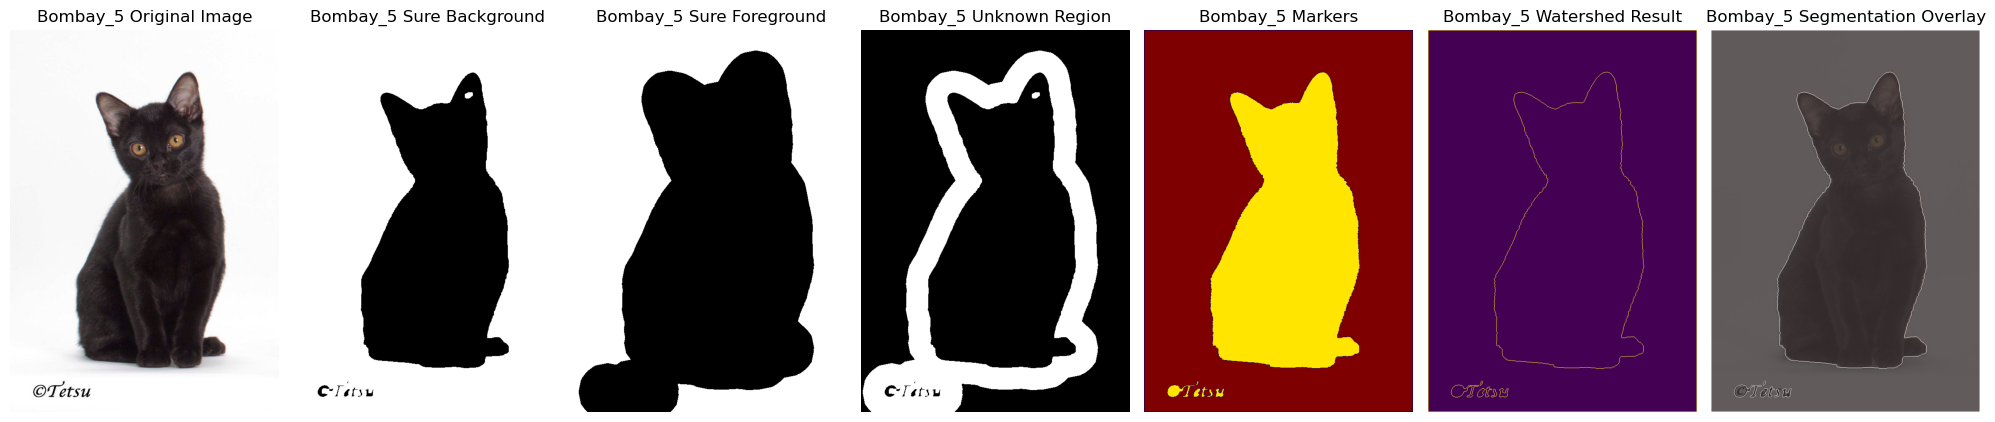

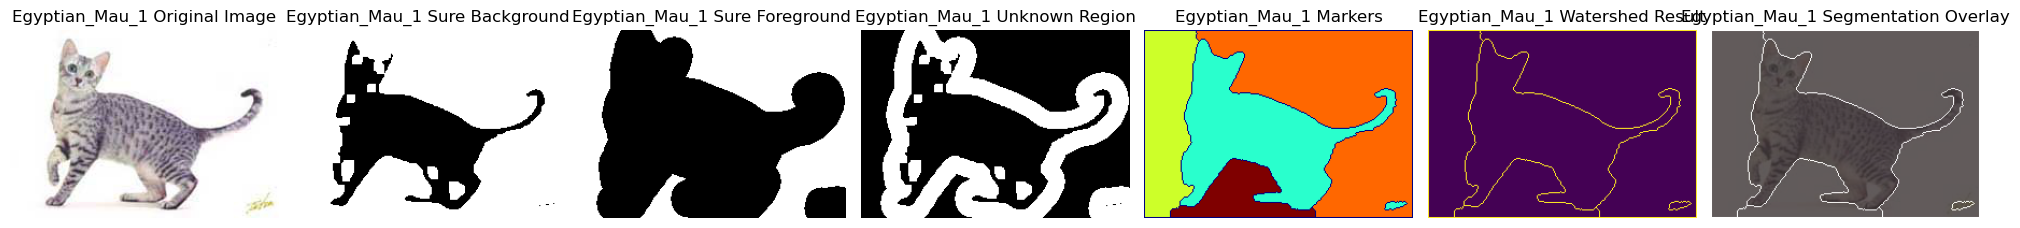

In [ ]:
for animal in animals:
    # Plot origional image
    plt.figure(figsize=(20, 10))
    plt.subplot(1, 7, 1)
    plt.imshow(animal.image)
    plt.title(f"{animal.name} Original Image")
    plt.axis("off")
    
    # Plot the sure background
    plt.subplot(1, 7, 2)
    plt.imshow(animal.sure_bg, cmap="gray")
    plt.title(f"{animal.name} Sure Background")
    plt.axis("off")

    # Plot the sure forground
    plt.subplot(1, 7, 3)
    plt.imshow(animal.sure_fg, cmap="gray")
    plt.title(f"{animal.name} Sure Foreground")
    plt.axis("off")

    # Plot the unknown region
    plt.subplot(1, 7, 4)
    plt.imshow(animal.unknown, cmap="grey")
    plt.title(f"{animal.name} Unknown Region")
    plt.axis("off")

    # Plot the marker regions
    plt.subplot(1, 7, 5)
    plt.imshow(animal.markers, cmap="jet")
    plt.title(f"{animal.name} Markers")
    plt.axis("off")

    # Plot the watershed result
    plt.subplot(1, 7, 6)
    plt.imshow(animal.watershed)
    plt.title(f"{animal.name} Watershed Result")
    plt.axis("off")

    # Plot watershed overlayed on the origional image
    plt.subplot(1, 7, 7)
    plt.imshow(animal.watershed, cmap="hot", alpha=0.8)
    plt.imshow(animal.image, alpha=0.2)

    plt.title(f"{animal.name} Segmentation Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

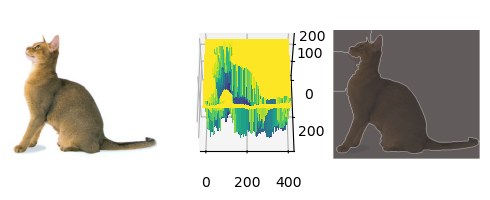

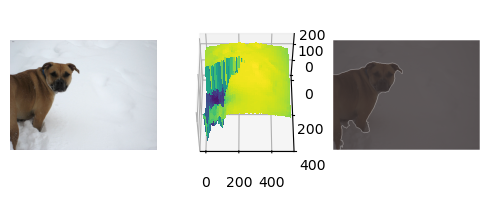

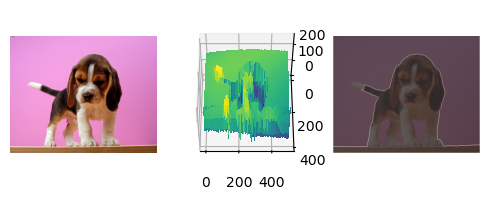

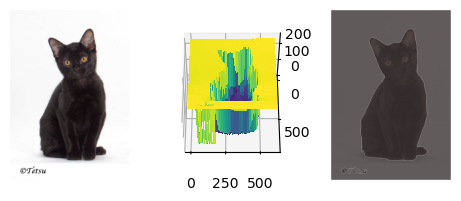

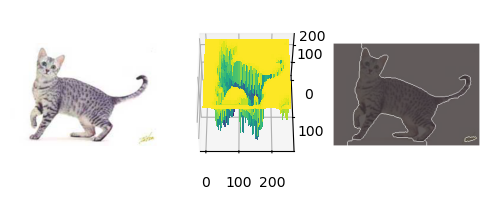

In [ ]:
# This wasn't really needed for the assignment, but was used for my own understanding of how watershed works.
for animal in animals:
    # Plot origional Image
    plt.figure(figsize=(5, 2))
    plt.subplot(1, 3, 1)
    plt.imshow(animal.image)
    plt.axis("off")

    # Plot the 3D plot of the image
    plt.subplot(1, 3, 2)
    plt.axis("off")

    # Make a mesh of the image and put the x and y values as the x and y values of the image
    h, w = animal.image_grayscale.shape
    X, Y = np.meshgrid(np.arange(w), np.arange(h))

    # Make an empty np.array
    marker_surface = np.zeros_like(animal.image_grayscale, dtype=np.uint8)

    # for each marker value, set the corresponding pixel to the marker value so we can see the different marker values on the 3D plot
    for marker_value in np.unique(animal.markers):
        if marker_value == -1:
            continue
        marker_surface[animal.markers == marker_value] = marker_value

    # Create the plot
    ax = plt.subplot(1, 3, 2, projection="3d")
    ax.plot_surface(X, Y, animal.image_grayscale, cmap="viridis", linewidth=0, antialiased=False)
    
    # Orientate the plot to make easier to compare to the origional image
    ax.view_init(elev=55, azim=90)
    ax.invert_xaxis()

    # Plot watershed overlayed on the origional image
    plt.subplot(1, 3, 3)
    plt.imshow(animal.watershed, cmap="hot", alpha=0.8)
    plt.imshow(animal.image, alpha=0.2)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
# iterate over the images and calculate IoU and Dice
for animal in animals:
    print(f"{animal.name} Watershed IoU: {compute_iou(animal.annotation_greyscale > 0, cv2.bitwise_not(animal.watershed) > 0):.4f}")

print("---------------------------------")

for animal in animals:
    print(f"{animal.name} Watershed Dice: {compute_dice(animal.annotation_greyscale > 0, cv2.bitwise_not(animal.watershed) > 0):.4f}")

Abyssinian_19 Watershed IoU: 0.9786
american_pit_bull_terrier_6 Watershed IoU: 0.9868
beagle_1 Watershed IoU: 0.9857
Bombay_5 Watershed IoU: 0.9898
Egyptian_Mau_1 Watershed IoU: 0.9613
---------------------------------
Abyssinian_19 Watershed Dice: 0.9892
american_pit_bull_terrier_6 Watershed Dice: 0.9933
beagle_1 Watershed Dice: 0.9928
Bombay_5 Watershed Dice: 0.9949
Egyptian_Mau_1 Watershed Dice: 0.9803


In [ ]:

for animal in animals:
    K = 2
    # K-means on the RGB values of the image
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    Z = animal.image.reshape((-1, 3))
    Z = np.float32(Z)
    _, labels, centers = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    centers = np.uint8(centers)
    animal.kmeans_mask_RGB = centers[labels.flatten()].reshape(animal.image.shape)

    # K-means on the HSV values of the image
    Z = cv2.cvtColor(animal.image, cv2.COLOR_RGB2HSV)
    Z = Z.reshape((-1, 3))
    Z = np.float32(Z)
    _, labels, centers = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    centers = np.uint8(centers)
    animal.kmeans_mask_HSV = centers[labels.flatten()].reshape(animal.image.shape)

    # K-means on the spatial features of the image
    h, w = animal.image.shape[:2]
    Z = []
    for y in range(h):
        for x in range(w):
           Z.append([x, y])
    Z = np.float32(Z)
    _, labels, centers = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    centers = np.uint8(centers[:, :3])
    mask = labels.reshape((h, w))
    animal.kmeans_mask_spatial = mask

    # K-means on the spatial features and RGB values of the image
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    Z = animal.image.reshape((-1, 3))
    h, w = animal.image.shape[:2]
    spatial_features = np.zeros((h * w, 5), dtype=np.float32)
    for y in range(h):
        for x in range(w):
            spatial_features[y * w + x, :3] = animal.image[y, x]
            spatial_features[y * w + x, 3] = x
            spatial_features[y * w + x, 4] = y
    _, labels, centers = cv2.kmeans(spatial_features, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    centers = np.uint8(centers[:, :3])
    animal.kmeans_mask_spatial_RGB = centers[labels.flatten()].reshape(animal.image.shape)
    

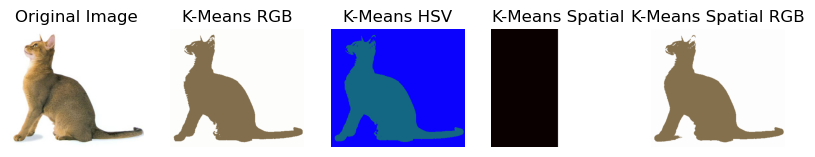

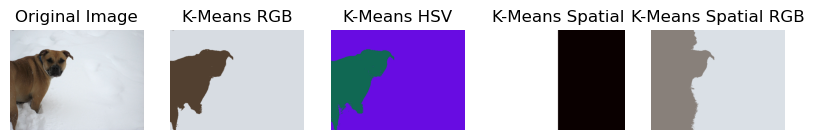

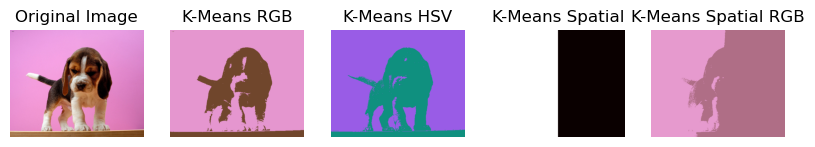

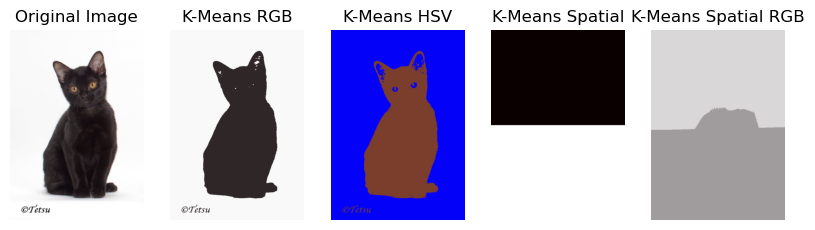

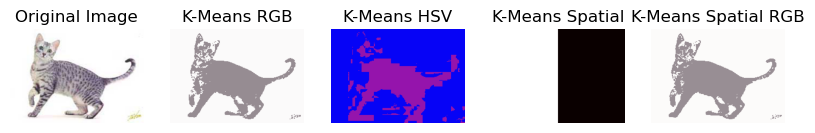

In [ ]:
for animal in animals:
    # plot the original image
    plt.figure(figsize=(10,5))
    plt.subplot(1, 5, 1)
    plt.imshow(animal.image)
    plt.title(f"Original Image")
    plt.axis("off")

    # plot the RGB k-means masks
    plt.subplot(1, 5, 2)
    plt.imshow(animal.kmeans_mask_RGB, cmap="hot")
    plt.title(f"K-Means RGB")
    plt.axis("off")

    # plot the HSV k-means masks
    plt.subplot(1, 5, 3)
    plt.imshow(animal.kmeans_mask_HSV, cmap="hot")
    plt.title(f"K-Means HSV")
    plt.axis("off")

    # plot the spatial k-means masks
    plt.subplot(1, 5, 4)
    plt.imshow(animal.kmeans_mask_spatial, cmap="hot")
    plt.title(f"K-Means Spatial")
    plt.axis("off")

    # plot the spatial RGB k-means masks
    plt.subplot(1, 5, 5)
    plt.imshow(animal.kmeans_mask_spatial_RGB, cmap="hot")
    plt.title(f"K-Means Spatial RGB")
    plt.axis("off")


In [ ]:
for animal in animals:
    gt = (animal.annotation_single_channel == 1).astype(np.uint8)

    # Convert clustered 3-channel outputs to grayscale first
    pred_rgb_gray = cv2.cvtColor(animal.kmeans_mask_RGB, cv2.COLOR_RGB2GRAY)
    pred_hsv_gray = cv2.cvtColor(cv2.cvtColor(animal.kmeans_mask_HSV, cv2.COLOR_HSV2RGB), cv2.COLOR_RGB2GRAY)
    pred_spatial_rgb_gray = cv2.cvtColor(animal.kmeans_mask_spatial_RGB, cv2.COLOR_RGB2GRAY)

    # Grayscale isn't binary, so apply Otsu's thresholding to get binary masks.
    _, pred_rgb_bin = cv2.threshold(pred_rgb_gray, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, pred_hsv_bin = cv2.threshold(pred_hsv_gray, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, pred_spatial_rgb_bin = cv2.threshold(pred_spatial_rgb_gray, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    pred_spatial_bin = (animal.kmeans_mask_spatial > 0).astype(np.uint8)

    # Calculate IoU and Dice for each mask
    rgb_iou = max(compute_iou(gt, pred_rgb_bin), compute_iou(gt, 1 - pred_rgb_bin))
    hsv_iou = max(compute_iou(gt, pred_hsv_bin), compute_iou(gt, 1 - pred_hsv_bin))
    spatial_iou = max(compute_iou(gt, pred_spatial_bin), compute_iou(gt, 1 - pred_spatial_bin))
    spatial_rgb_iou = max(compute_iou(gt, pred_spatial_rgb_bin), compute_iou(gt, 1 - pred_spatial_rgb_bin))

    print(f"{animal.name} RGB IoU: {rgb_iou:.4f}, Dice: {max(compute_dice(gt, pred_rgb_bin), compute_dice(gt, 1 - pred_rgb_bin)):.4f}")
    print(f"{animal.name} HSV IoU: {hsv_iou:.4f}, Dice: {max(compute_dice(gt, pred_hsv_bin), compute_dice(gt, 1 - pred_hsv_bin)):.4f}")
    print(f"{animal.name} Spatial IoU: {spatial_iou:.4f}, Dice: {max(compute_dice(gt, pred_spatial_bin), compute_dice(gt, 1 - pred_spatial_bin)):.4f}")
    print(f"{animal.name} Spatial RGB IoU: {spatial_rgb_iou:.4f}, Dice: {max(compute_dice(gt, pred_spatial_rgb_bin), compute_dice(gt, 1 - pred_spatial_rgb_bin)):.4f}")
    print("---------------------------------")

Abyssinian_19 RGB IoU: 0.7891, Dice: 0.8821
Abyssinian_19 HSV IoU: 0.7932, Dice: 0.8847
Abyssinian_19 Spatial IoU: 0.3676, Dice: 0.5375
Abyssinian_19 Spatial RGB IoU: 0.7754, Dice: 0.8735
---------------------------------
american_pit_bull_terrier_6 RGB IoU: 0.6855, Dice: 0.8134
american_pit_bull_terrier_6 HSV IoU: 0.6848, Dice: 0.8130
american_pit_bull_terrier_6 Spatial IoU: 0.2597, Dice: 0.4123
american_pit_bull_terrier_6 Spatial RGB IoU: 0.3725, Dice: 0.5428
---------------------------------
beagle_1 RGB IoU: 0.5635, Dice: 0.7208
beagle_1 HSV IoU: 0.6361, Dice: 0.7776
beagle_1 Spatial IoU: 0.2273, Dice: 0.3704
beagle_1 Spatial RGB IoU: 0.3271, Dice: 0.4930
---------------------------------
Bombay_5 RGB IoU: 0.8470, Dice: 0.9172
Bombay_5 HSV IoU: 0.8336, Dice: 0.9092
Bombay_5 Spatial IoU: 0.2743, Dice: 0.4305
Bombay_5 Spatial RGB IoU: 0.3282, Dice: 0.4942
---------------------------------
Egyptian_Mau_1 RGB IoU: 0.6879, Dice: 0.8151
Egyptian_Mau_1 HSV IoU: 0.5008, Dice: 0.6674
Egypti

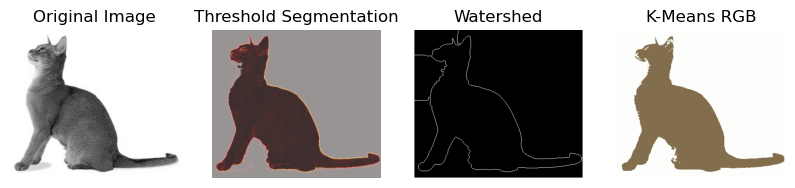

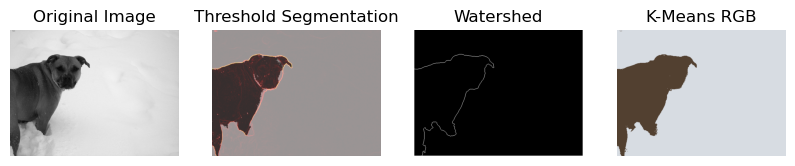

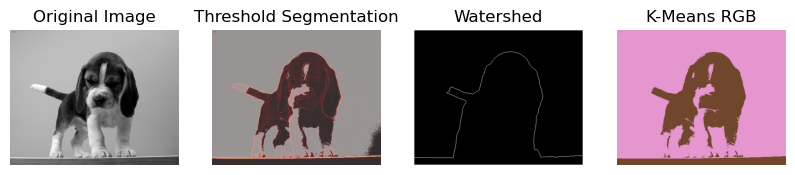

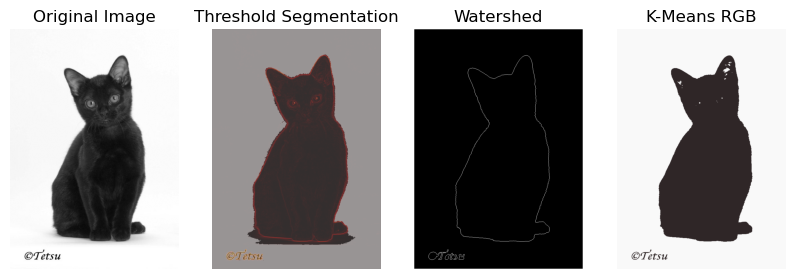

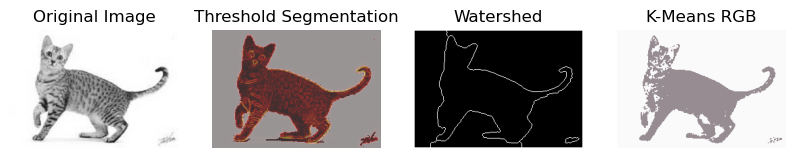

In [ ]:


for animal in animals:
    # Plot original
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 4, 1)
    plt.imshow(animal.image_grayscale, cmap="gray")
    plt.title(f"Original Image")
    plt.axis("off")

    # Plot output of sobel + thresholding
    plt.subplot(1, 4, 2)
    sobel_x = cv2.Sobel(animal.image_grayscale, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(animal.image_grayscale, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.sqrt(sobel_x**2 + sobel_y**2)
    sobel = np.uint8(sobel / (np.max(sobel) + 1e-8) * 255)

    _, binary = cv2.threshold(animal.image_grayscale, animal.Threshold, 255, cv2.THRESH_BINARY)
    animal.threshold_segmentation = binary

    plt.imshow(sobel, cmap="hot", alpha=0.7)
    plt.imshow(binary, cmap="grey", alpha=0.4)
    plt.title(f"Threshold Segmentation")
    plt.axis("off")

    # Plot watershed output
    plt.subplot(1, 4, 3)
    plt.imshow(animal.watershed, cmap="gray")
    plt.title(f"Watershed")
    plt.axis("off")

    # Plot the RGB k-means masks
    plt.subplot(1, 4, 4)
    plt.imshow(animal.kmeans_mask_RGB, cmap="gray")
    plt.title(f"K-Means RGB")
    plt.axis("off")
    plt.show()